# Assignment 2



In [19]:
%pip install -q "transformers>=4.52,<5" "datasets>=3,<5" "accelerate>=1,<2" "nltk>=3.9" "matplotlib>=3.8" tqdm safetensors


In [20]:
import gc
import json
import math
import random
import shutil
import time
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import torch
import torch.nn.functional as F
from datasets import load_dataset
from nltk.tokenize.treebank import TreebankWordDetokenizer
from torch import nn
from torch.distributions import Categorical
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    PreTrainedModel,
    PretrainedConfig,
    get_cosine_schedule_with_warmup,
)
from transformers.modeling_outputs import CausalLMOutput

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("Select Runtime > Change runtime type > T4 GPU, then run again.")

DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
GPU: Tesla T4


## Data and tokenizer




In [21]:
WORK_DIR = Path("/content/dl4nlp_a1_2")
DATA_DIR = WORK_DIR / "data"
OUTPUT_DIR = WORK_DIR / "outputs"
WORK_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ARCHIVES = {
    "a1_1.zip": "https://www.cse.chalmers.se/~richajo/waspnlp2026/a1_1.zip",
    "a1_2.zip": "https://www.cse.chalmers.se/~richajo/waspnlp2026/a1_2.zip",
}

for filename, url in ARCHIVES.items():
    uploaded = Path("/content") / filename
    archive = uploaded if uploaded.exists() else WORK_DIR / filename
    if not archive.exists():
        print("Downloading", filename)
        urllib.request.urlretrieve(url, archive)
    target = DATA_DIR / archive.stem
    if not target.exists():
        target.mkdir(parents=True)
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(target)

train_candidates = list(DATA_DIR.rglob("train.txt"))
val_candidates = list(DATA_DIR.rglob("val.txt"))
if not train_candidates or not val_candidates:
    raise FileNotFoundError("train.txt and val.txt were not found.")

TRAIN_FILE = train_candidates[0]
VAL_FILE = val_candidates[0]

HP = {
    "max_vocab_size": 15_000,
    "max_length": 64,
    "hidden_size": 256,
    "intermediate_size": 768,
    "num_attention_heads": 8,
    "num_hidden_layers": 2,
    "rope_theta": 10_000.0,
    "rms_norm_eps": 1e-6,
    "epochs": 10,
    "train_batch_size": 64,
    "eval_batch_size": 128,
    "learning_rate": 3e-4,
    "weight_decay": 0.1,
    "warmup_ratio": 0.05,
    "max_grad_norm": 1.0,
    "num_workers": 2,
}

print("Training file:", TRAIN_FILE)
print("Validation file:", VAL_FILE)
print(json.dumps(HP, indent=2))


Training file: /content/dl4nlp_a1_2/data/a1_1/a1_1/train.txt
Validation file: /content/dl4nlp_a1_2/data/a1_1/a1_1/val.txt
{
  "max_vocab_size": 15000,
  "max_length": 64,
  "hidden_size": 256,
  "intermediate_size": 768,
  "num_attention_heads": 8,
  "num_hidden_layers": 2,
  "rope_theta": 10000.0,
  "rms_norm_eps": 1e-06,
  "epochs": 10,
  "train_batch_size": 64,
  "eval_batch_size": 128,
  "learning_rate": 0.0003,
  "weight_decay": 0.1,
  "warmup_ratio": 0.05,
  "max_grad_norm": 1.0,
  "num_workers": 2
}


In [22]:
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]


def lowercase_tokenizer(text):
    return [token.lower() for token in nltk.word_tokenize(text)]


class A1Tokenizer:
    def __init__(self, str_to_int, model_max_length):
        self.str_to_int = dict(str_to_int)
        self.int_to_str = {idx: token for token, idx in self.str_to_int.items()}
        self.model_max_length = int(model_max_length)
        self.pad_token, self.unk_token, self.bos_token, self.eos_token = SPECIAL_TOKENS
        self.pad_token_id = self.str_to_int[self.pad_token]
        self.unk_token_id = self.str_to_int[self.unk_token]
        self.bos_token_id = self.str_to_int[self.bos_token]
        self.eos_token_id = self.str_to_int[self.eos_token]

    def __len__(self):
        return len(self.str_to_int)

    def encode(self, text, add_special_tokens=True):
        tokens = lowercase_tokenizer(text)
        if add_special_tokens:
            tokens = tokens[: self.model_max_length - 2]
            tokens = [self.bos_token, *tokens, self.eos_token]
        else:
            tokens = tokens[: self.model_max_length]
        return [self.str_to_int.get(token, self.unk_token_id) for token in tokens]

    def decode(self, ids, skip_special_tokens=True):
        tokens = [self.int_to_str.get(int(idx), self.unk_token) for idx in ids]
        if skip_special_tokens:
            tokens = [token for token in tokens if token not in SPECIAL_TOKENS]
        return TreebankWordDetokenizer().detokenize(tokens)

    def save_pretrained(self, directory):
        directory = Path(directory)
        directory.mkdir(parents=True, exist_ok=True)
        payload = {
            "str_to_int": self.str_to_int,
            "model_max_length": self.model_max_length,
        }
        (directory / "tokenizer.json").write_text(json.dumps(payload), encoding="utf-8")

    @classmethod
    def from_pretrained(cls, directory):
        payload = json.loads((Path(directory) / "tokenizer.json").read_text(encoding="utf-8"))
        return cls(payload["str_to_int"], payload["model_max_length"])


In [24]:
def encode_batch(batch):
    return {"input_ids": [tokenizer.encode(text) for text in batch["text"]]}


encoded = raw.map(
    encode_batch,
    batched=True,
    batch_size=1_000,
    num_proc=2,
    remove_columns=["text"],
    desc="Tokenizing full corpus",
)
encoded = encoded.filter(lambda row: len(row["input_ids"]) >= 3, num_proc=2)


class LanguageModelCollator:
    def __init__(self, pad_token_id):
        self.pad_token_id = int(pad_token_id)

    def __call__(self, examples):
        max_len = max(len(example["input_ids"]) for example in examples)
        input_ids = torch.full(
            (len(examples), max_len), self.pad_token_id, dtype=torch.long
        )
        attention_mask = torch.zeros((len(examples), max_len), dtype=torch.long)
        for row, example in enumerate(examples):
            ids = torch.tensor(example["input_ids"], dtype=torch.long)
            input_ids[row, : len(ids)] = ids
            attention_mask[row, : len(ids)] = 1
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


collator = LanguageModelCollator(tokenizer.pad_token_id)
test_batch = collator([encoded["train"][0], encoded["train"][1]])
assert test_batch["input_ids"].shape == test_batch["labels"].shape
assert torch.all(test_batch["labels"][test_batch["attention_mask"] == 0] == -100)
print({split: len(encoded[split]) for split in encoded})
print({key: tuple(value.shape) for key, value in test_batch.items()})


{'train': 147059, 'validation': 17874}
{'input_ids': (2, 64), 'attention_mask': (2, 64), 'labels': (2, 64)}


## Transformer implementation





In [23]:
raw = load_dataset(
    "text",
    data_files={"train": str(TRAIN_FILE), "validation": str(VAL_FILE)},
)
raw = raw.filter(lambda row: bool(row["text"].strip()), num_proc=2)

counter = Counter()
batch_size = 2_000
for start in tqdm(range(0, len(raw["train"]), batch_size), desc="Building vocabulary"):
    texts = raw["train"][start : start + batch_size]["text"]
    for text in texts:
        counter.update(lowercase_tokenizer(text))

str_to_int = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
for token, _ in counter.most_common():
    if token not in str_to_int:
        str_to_int[token] = len(str_to_int)
    if len(str_to_int) == HP["max_vocab_size"]:
        break

tokenizer = A1Tokenizer(str_to_int, HP["max_length"])
assert len(tokenizer) <= HP["max_vocab_size"]
assert tokenizer.encode("A short test.")[0] == tokenizer.bos_token_id
assert tokenizer.encode("A short test.")[-1] == tokenizer.eos_token_id
print("Vocabulary size:", len(tokenizer))
print(tokenizer.encode("A short test."), tokenizer.decode(tokenizer.encode("A short test.")))


Building vocabulary:   0%|          | 0/74 [00:00<?, ?it/s]

Vocabulary size: 15000
[2, 11, 506, 965, 6, 3] a short test.


In [25]:
class A2ModelConfig(PretrainedConfig):
    model_type = "a2_transformer"

    def __init__(
        self,
        vocab_size=15_000,
        hidden_size=256,
        intermediate_size=768,
        num_attention_heads=8,
        num_hidden_layers=2,
        rope_theta=10_000.0,
        hidden_act="silu",
        max_position_embeddings=64,
        rms_norm_eps=1e-6,
        initializer_range=0.02,
        pad_token_id=0,
        bos_token_id=2,
        eos_token_id=3,
        **kwargs,
    ):
        kwargs.setdefault("tie_word_embeddings", False)
        super().__init__(
            pad_token_id=pad_token_id,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            **kwargs,
        )
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_attention_heads = num_attention_heads
        self.num_hidden_layers = num_hidden_layers
        self.rope_theta = rope_theta
        self.hidden_act = hidden_act
        self.max_position_embeddings = max_position_embeddings
        self.rms_norm_eps = rms_norm_eps
        self.initializer_range = initializer_range


class A2RMSNorm(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.eps = config.rms_norm_eps
        self.weight = nn.Parameter(torch.ones(config.hidden_size))

    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        values = hidden_states.float()
        variance = values.pow(2).mean(dim=-1, keepdim=True)
        normalized = values * torch.rsqrt(variance + self.eps)
        return (self.weight * normalized).to(input_dtype)


def rotate_half(x):
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q, k, rope_rotations, unsqueeze_dim=1):
    cos, sin = rope_rotations
    cos = cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    q_dtype, k_dtype = q.dtype, k.dtype
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed.to(q_dtype), k_embed.to(k_dtype)


class A2RotaryEmbedding(nn.Module):
    def __init__(self, config, device=None):
        super().__init__()
        head_dim = config.hidden_size // config.num_attention_heads
        inv_freq = 1.0 / (
            config.rope_theta
            ** (torch.arange(0, head_dim, 2, dtype=torch.float, device=device) / head_dim)
        )
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    @torch.no_grad()
    def forward(self, x):
        position_ids = torch.arange(x.shape[1], device=x.device).unsqueeze(0)
        inv_freq = self.inv_freq[None, :, None].float().expand(1, -1, 1)
        positions = position_ids[:, None, :].float()
        device_type = x.device.type if x.device.type != "mps" else "cpu"
        with torch.autocast(device_type=device_type, enabled=False):
            frequencies = (inv_freq @ positions).transpose(1, 2)
            embeddings = torch.cat((frequencies, frequencies), dim=-1)
            return embeddings.cos(), embeddings.sin()


In [26]:
class A2MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        if config.hidden_act != "silu":
            raise ValueError("A2MLP implements SwiGLU with SiLU.")
        self.gate_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.up_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.down_proj = nn.Linear(config.intermediate_size, config.hidden_size, bias=False)

    def forward(self, hidden_states):
        gated = F.silu(self.gate_proj(hidden_states)) * self.up_proj(hidden_states)
        return self.down_proj(gated)


class A2Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        if config.hidden_size % config.num_attention_heads != 0:
            raise ValueError("hidden_size must be divisible by num_attention_heads.")
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        if self.head_dim % 2 != 0:
            raise ValueError("RoPE requires an even attention head dimension.")

        self.q_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.k_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.v_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.o_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.q_norm = A2RMSNorm(config)
        self.k_norm = A2RMSNorm(config)

    def forward(self, hidden_states, rope_rotations):
        batch_size, sequence_length, _ = hidden_states.shape
        q = self.q_norm(self.q_proj(hidden_states))
        k = self.k_norm(self.k_proj(hidden_states))
        v = self.v_proj(hidden_states)

        q = q.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        q, k = apply_rotary_pos_emb(q, k, rope_rotations)

        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=0.0)
        attn_out = attn_out.transpose(1, 2).contiguous().reshape(
            batch_size, sequence_length, self.hidden_size
        )
        return self.o_proj(attn_out)


In [27]:
class A2DecoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attn = A2Attention(config)
        self.mlp = A2MLP(config)
        self.post_attention_layernorm = A2RMSNorm(config)
        self.post_feedforward_layernorm = A2RMSNorm(config)

    def forward(self, hidden_states, rope_rotations):
        residual = hidden_states
        hidden_states = self.self_attn(hidden_states, rope_rotations)
        hidden_states = residual + self.post_attention_layernorm(hidden_states)

        residual = hidden_states
        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + self.post_feedforward_layernorm(hidden_states)
        return hidden_states


class A2Transformer(PreTrainedModel):
    config_class = A2ModelConfig
    main_input_name = "input_ids"

    def __init__(self, config):
        super().__init__(config)
        self.embed_tokens = nn.Embedding(
            config.vocab_size, config.hidden_size, padding_idx=config.pad_token_id
        )
        self.rotary_emb = A2RotaryEmbedding(config)
        self.layers = nn.ModuleList(
            [A2DecoderLayer(config) for _ in range(config.num_hidden_layers)]
        )
        self.norm = A2RMSNorm(config)
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        self.post_init()

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=self.config.initializer_range)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=self.config.initializer_range)
            if module.padding_idx is not None:
                with torch.no_grad():
                    module.weight[module.padding_idx].zero_()

    def get_input_embeddings(self):
        return self.embed_tokens

    def set_input_embeddings(self, value):
        self.embed_tokens = value

    def get_output_embeddings(self):
        return self.lm_head

    def forward(self, input_ids, labels=None, attention_mask=None, **kwargs):
        if input_ids.ndim != 2:
            raise ValueError("input_ids must have shape (batch, sequence).")
        if input_ids.shape[1] > self.config.max_position_embeddings:
            raise ValueError("Sequence exceeds max_position_embeddings.")

        rope_rotations = self.rotary_emb(input_ids)
        hidden_states = self.embed_tokens(input_ids)
        for layer in self.layers:
            hidden_states = layer(hidden_states, rope_rotations)
        logits = self.lm_head(self.norm(hidden_states))

        loss = None
        if labels is not None:
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss = F.cross_entropy(
                shift_logits.view(-1, self.config.vocab_size),
                shift_labels.view(-1),
                ignore_index=-100,
            )
        return CausalLMOutput(loss=loss, logits=logits)


In [28]:
test_config = A2ModelConfig(
    vocab_size=101,
    hidden_size=64,
    intermediate_size=192,
    num_attention_heads=4,
    num_hidden_layers=2,
    max_position_embeddings=16,
)
test_ids = torch.randint(0, test_config.vocab_size, (3, 11))
test_model = A2Transformer(test_config).eval()
test_rope = test_model.rotary_emb(test_ids)

assert A2MLP(test_config)(torch.randn(3, 11, 64)).shape == (3, 11, 64)
assert A2RMSNorm(test_config)(torch.randn(3, 11, 64)).shape == (3, 11, 64)
assert A2Attention(test_config)(torch.randn(3, 11, 64), test_rope).shape == (3, 11, 64)
assert A2DecoderLayer(test_config)(torch.randn(3, 11, 64), test_rope).shape == (3, 11, 64)

labels = test_ids.clone()
out = test_model(test_ids, labels=labels)
assert out.logits.shape == (3, 11, test_config.vocab_size)
assert torch.isfinite(out.loss)
assert all(module.bias is None for module in test_model.modules() if isinstance(module, nn.Linear))

changed = test_ids.clone()
changed[:, -1] = (changed[:, -1] + 1) % test_config.vocab_size
with torch.no_grad():
    original_logits = test_model(test_ids).logits[:, :-1]
    changed_logits = test_model(changed).logits[:, :-1]
assert torch.allclose(original_logits, changed_logits, atol=1e-6), "Causal masking failed."
print("All component, loss, bias, and causality checks passed.")
del test_model, test_ids, labels, out, original_logits, changed_logits


All component, loss, bias, and causality checks passed.


## Full training run




In [29]:
train_loader = DataLoader(
    encoded["train"],
    batch_size=HP["train_batch_size"],
    shuffle=True,
    collate_fn=collator,
    num_workers=HP["num_workers"],
    pin_memory=True,
    persistent_workers=HP["num_workers"] > 0,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    encoded["validation"],
    batch_size=HP["eval_batch_size"],
    shuffle=False,
    collate_fn=collator,
    num_workers=HP["num_workers"],
    pin_memory=True,
    persistent_workers=HP["num_workers"] > 0,
)

config = A2ModelConfig(
    vocab_size=len(tokenizer),
    hidden_size=HP["hidden_size"],
    intermediate_size=HP["intermediate_size"],
    num_attention_heads=HP["num_attention_heads"],
    num_hidden_layers=HP["num_hidden_layers"],
    rope_theta=HP["rope_theta"],
    max_position_embeddings=HP["max_length"],
    rms_norm_eps=HP["rms_norm_eps"],
    pad_token_id=tokenizer.pad_token_id,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
model = A2Transformer(config).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
training_example_count = len(encoded["train"])
validation_example_count = len(encoded["validation"])
print(f"Parameters: {parameter_count:,}")
print("Train batches:", len(train_loader), "Validation batches:", len(val_loader))


Parameters: 9,386,240
Train batches: 2298 Validation batches: 140


In [30]:
def make_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except TypeError:
        return torch.cuda.amp.GradScaler(enabled=True)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=HP["learning_rate"],
    weight_decay=HP["weight_decay"],
    fused=True,
)
total_steps = len(train_loader) * HP["epochs"]
warmup_steps = int(total_steps * HP["warmup_ratio"])
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = make_grad_scaler()


def run_epoch(loader, training):
    model.train(training)
    total_nll = 0.0
    total_tokens = 0
    progress = tqdm(loader, desc="train" if training else "validation", leave=False)
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch in progress:
            input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            token_count = int((labels[:, 1:] != -100).sum().item())

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(input_ids=input_ids, labels=labels)

            if training:
                scaler.scale(outputs.loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), HP["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_nll += float(outputs.loss.detach()) * token_count
            total_tokens += token_count
            progress.set_postfix(loss=f"{total_nll / max(total_tokens, 1):.4f}")

    mean_loss = total_nll / total_tokens
    return {
        "loss": mean_loss,
        "perplexity": math.exp(mean_loss),
        "tokens": total_tokens,
    }


In [31]:
history = []
model_dir = OUTPUT_DIR / "a2_transformer_full"

for epoch in range(1, HP["epochs"] + 1):
    started = time.time()
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(val_loader, training=False)
    record = {
        "epoch": epoch,
        "seconds": time.time() - started,
        "train_loss": train_metrics["loss"],
        "train_perplexity": train_metrics["perplexity"],
        "validation_loss": val_metrics["loss"],
        "validation_perplexity": val_metrics["perplexity"],
    }
    history.append(record)
    print(json.dumps(record, indent=2))

    model.save_pretrained(model_dir, safe_serialization=True)
    tokenizer.save_pretrained(model_dir)
    (OUTPUT_DIR / "training_history.json").write_text(
        json.dumps(history, indent=2), encoding="utf-8"
    )


train:   0%|          | 0/2298 [00:00<?, ?it/s]

validation:   0%|          | 0/140 [00:00<?, ?it/s]

{
  "epoch": 1,
  "seconds": 103.30081272125244,
  "train_loss": 5.570241668612272,
  "train_perplexity": 262.49752898903625,
  "validation_loss": 4.650419091569493,
  "validation_perplexity": 104.62882544868371
}


train:   0%|          | 0/2298 [00:00<?, ?it/s]

validation:   0%|          | 0/140 [00:00<?, ?it/s]

...

validation:   0%|          | 0/140 [00:00<?, ?it/s]

{
  "epoch": 9,
  "seconds": 83.24292159080505,
  "train_loss": 3.5062459005299016,
  "train_perplexity": 33.32293506252857,
  "validation_loss": 4.190650100111777,
  "validation_perplexity": 66.06572633882814
}


train:   0%|          | 0/2298 [00:00<?, ?it/s]

validation:   0%|          | 0/140 [00:00<?, ?it/s]

{
  "epoch": 10,
  "seconds": 83.12904787063599,
  "train_loss": 3.472494847978911,
  "train_perplexity": 32.21701882873893,
  "validation_loss": 4.196407219078594,
  "validation_perplexity": 66.4471715441387
}


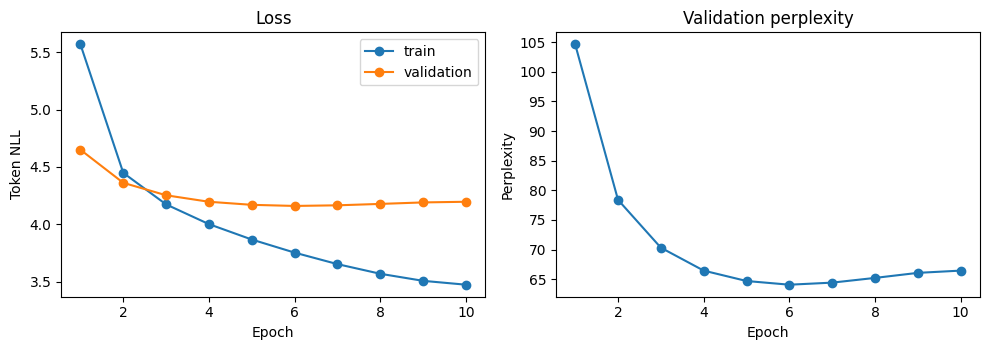

Saved model and tokenizer reload successfully.


In [32]:
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label="train")
axes[0].plot(epochs, [row["validation_loss"] for row in history], marker="o", label="validation")
axes[0].set(xlabel="Epoch", ylabel="Token NLL", title="Loss")
axes[0].legend()
axes[1].plot(epochs, [row["validation_perplexity"] for row in history], marker="o")
axes[1].set(xlabel="Epoch", ylabel="Perplexity", title="Validation perplexity")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

reloaded_tokenizer = A1Tokenizer.from_pretrained(model_dir)
reloaded_model = A2Transformer.from_pretrained(model_dir).to(DEVICE).eval()
probe = torch.tensor([reloaded_tokenizer.encode("he lives in san")[:-1]], device=DEVICE)
with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16):
    before = model(probe).logits
    after = reloaded_model(probe).logits
assert torch.allclose(before, after, atol=1e-4, rtol=1e-4)
model = reloaded_model
tokenizer = reloaded_tokenizer
print("Saved model and tokenizer reload successfully.")


## Prediction, sampling, and OLMo-2 comparison




In [33]:
def prompt_ids(text):
    ids = tokenizer.encode(text)
    return ids[:-1] if ids and ids[-1] == tokenizer.eos_token_id else ids


@torch.no_grad()
def predict_next_tokens(model, tokenizer, prompt, n=10):
    ids = prompt_ids(prompt)
    input_ids = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        logits = model(input_ids=input_ids).logits[0, -1].float()
    for blocked in [tokenizer.pad_token_id, tokenizer.bos_token_id, tokenizer.unk_token_id]:
        logits[blocked] = -torch.inf
    values, indices = torch.topk(logits, k=min(n, logits.numel()))
    probabilities = torch.softmax(values, dim=-1)
    return [
        {"token": tokenizer.int_to_str[int(idx)], "probability_within_top_n": float(prob)}
        for idx, prob in zip(indices, probabilities)
    ]


print(json.dumps(predict_next_tokens(model, tokenizer, "he lives in san"), indent=2))


[
  {
    "token": "francisco",
    "probability_within_top_n": 0.5335289835929871
  },
  {
    "token": "diego",
    "probability_within_top_n": 0.1858288049697876
  },
  {
    "token": "antonio",
    "probability_within_top_n": 0.10588207095861435
  },
  {
    "token": "juan",
    "probability_within_top_n": 0.05241542309522629
  },
  {
    "token": "crist\u00f3bal",
    "probability_within_top_n": 0.036878857761621475
  },
  {
    "token": "jose",
    "probability_within_top_n": 0.03491619974374771
  },
  {
    "token": "salvador",
    "probability_within_top_n": 0.017420338466763496
  },
  {
    "token": "francesco",
    "probability_within_top_n": 0.015253758989274502
  },
  {
    "token": "jos\u00e9",
    "probability_within_top_n": 0.009251872077584267
  },
  {
    "token": "giovanni",
    "probability_within_top_n": 0.008623693138360977
  }
]


In [34]:
@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_length=80, temperature=1.0, topk=50):
    if temperature <= 0:
        raise ValueError("temperature must be greater than zero.")
    if topk < 1:
        raise ValueError("topk must be at least one.")

    generated = prompt_ids(prompt)
    for _ in range(max_length):
        context = generated[-model.config.max_position_embeddings :]
        input_ids = torch.tensor([context], dtype=torch.long, device=DEVICE)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            next_logits = model(input_ids=input_ids).logits[0, -1].float()

        for blocked in [tokenizer.pad_token_id, tokenizer.bos_token_id, tokenizer.unk_token_id]:
            next_logits[blocked] = -torch.inf
        k = min(topk, next_logits.numel())
        top_values, top_indices = torch.topk(next_logits / temperature, k=k)
        next_id = int(top_indices[Categorical(logits=top_values).sample()].item())
        generated.append(next_id)
        if next_id == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated, skip_special_tokens=True)


prompts = [
    "In natural language processing, a Transformer",
    "Is Stockholm the capital of Sweden? Answer yes or no. The answer is",
    "Write a Python program that reverses a list.",
]
sampling_settings = [
    {"temperature": 0.7, "topk": 20},
    {"temperature": 1.0, "topk": 50},
    {"temperature": 1.3, "topk": 100},
]

custom_generations = []
for prompt in prompts:
    for settings in sampling_settings:
        text = generate_text(model, tokenizer, prompt, max_length=60, **settings)
        row = {"prompt": prompt, **settings, "text": text}
        custom_generations.append(row)
        print(json.dumps(row, ensure_ascii=False, indent=2))

(OUTPUT_DIR / "custom_model_generations.json").write_text(
    json.dumps(custom_generations, ensure_ascii=False, indent=2), encoding="utf-8"
)


{
  "prompt": "In natural language processing, a Transformer",
  "temperature": 0.7,
  "topk": 20,
  "text": "in natural language processing, a is a computer program which consists of a computer program that consists of five to ten bits, each of which is a single instruction . a program is usually called a computer program, which is in a cpu state or another program, but usually has a memory of a program or a"
}
{
  "prompt": "In natural language processing, a Transformer",
  "temperature": 1.0,
  "topk": 50,
  "text": "in natural language processing, a is a type of communication unit that produces a product of different programming languages . in addition, this is referred to as a dialect or a \"language\"."
}
{
  "prompt": "In natural language processing, a Transformer",
  "temperature": 1.3,
  "topk": 100,
  "text": "in natural language processing, a function is also given by the value {the general law: article 2, 2\" d\" -\" n\", where − 1 is defined as:"
}
{
  "prompt": "Is Stockh

3129

In [35]:
# Free training-state memory before loading the 1B-parameter comparison model.
del optimizer, scheduler, scaler, train_loader, val_loader, encoded, raw
del model, reloaded_model
gc.collect()
torch.cuda.empty_cache()

PRETRAINED_NAME = "allenai/OLMo-2-0425-1B"
pretrained_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_NAME)
pretrained_model = AutoModelForCausalLM.from_pretrained(
    PRETRAINED_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
).eval()
if pretrained_tokenizer.pad_token_id is None:
    pretrained_tokenizer.pad_token = pretrained_tokenizer.eos_token

pretrained_device = next(pretrained_model.parameters()).device
pretrained_generations = []
for prompt in prompts:
    inputs = pretrained_tokenizer(prompt, return_tensors="pt").to(pretrained_device)
    with torch.no_grad():
        output_ids = pretrained_model.generate(
            **inputs,
            do_sample=True,
            temperature=0.8,
            top_k=50,
            max_new_tokens=60,
            eos_token_id=pretrained_tokenizer.eos_token_id,
            pad_token_id=pretrained_tokenizer.pad_token_id,
        )
    text = pretrained_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    row = {"prompt": prompt, "temperature": 0.8, "topk": 50, "text": text}
    pretrained_generations.append(row)
    print(json.dumps(row, ensure_ascii=False, indent=2))

(OUTPUT_DIR / "olmo2_generations.json").write_text(
    json.dumps(pretrained_generations, ensure_ascii=False, indent=2), encoding="utf-8"
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{
  "prompt": "In natural language processing, a Transformer",
  "temperature": 0.8,
  "topk": 50,
  "text": "In natural language processing, a Transformer is a kind of neural network architecture capable of performing complex tasks without any human intervention. It uses a special structure called attention mechanism to identify relevant data and extract meaningful information from various sources. The attention mechanism allows the Transformer to learn how to handle different types of data efficiently. This makes it possible for the"
}
{
  "prompt": "Is Stockholm the capital of Sweden? Answer yes or no. The answer is",
  "temperature": 0.8,
  "topk": 50,
  "text": "Is Stockholm the capital of Sweden? Answer yes or no. The answer is yes. Sweden is a country in northern Europe. It is between Norway and Finland and Denmark to the south. It is the size of the U.S. state of Nebraska. But Sweden is almost as big as the U.S. state of Alaska. Because it is so big, the Swedish people grow"
}


1469

In [36]:
summary = {
    "hyperparameters": HP,
    "vocabulary_size": len(tokenizer),
    "parameter_count": parameter_count,
    "training_examples": training_example_count,
    "validation_examples": validation_example_count,
    "final_metrics": history[-1],
    "pretrained_comparator": PRETRAINED_NAME,
}
(OUTPUT_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

archive_base = WORK_DIR / "A1_2_full_run_outputs"
archive_path = Path(shutil.make_archive(str(archive_base), "zip", root_dir=OUTPUT_DIR))
print("Output archive:", archive_path)

from google.colab import files
files.download(str(archive_path))


Output archive: /content/dl4nlp_a1_2/A1_2_full_run_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>